# EDA básico NOC - Sprint 6

**Proyecto:** Modelos de inteligencia artificial para la detección proactiva de fallas físicas en infraestructura de red de telecomunicaciones en entornos NOC.

Este cuaderno muestra el análisis exploratorio de datos del Sprint 6, usando únicamente datasets **procesados y anonimizados**. No se publican archivos crudos por confidencialidad operativa.

**Fuentes integradas en este sprint:**

1. Incidentes históricos TX/IP del NOC.
2. Alarmas actuales de red para complementar el análisis operativo.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

BASE = Path('..')
DATA_DIR = BASE / 'data' / 'processed'
RESULTS_DIR = BASE / 'results'

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)


## 1. Carga de datos procesados

Los archivos utilizados en este notebook son versiones anonimizadas, ubicadas en `data/processed/`.


In [2]:
incidents = pd.read_csv(DATA_DIR / 'incidents_noc_tx_ip_anon_sprint6.csv')
alarms = pd.read_csv(DATA_DIR / 'current_alarms_anon_sprint6.csv')
metrics = pd.read_csv(RESULTS_DIR / 'metrics_ab_sprint6.csv')

summary = {
    'incidentes_tx_ip_anonimizados': len(incidents),
    'alarmas_actuales_anonimizadas': len(alarms),
    'columnas_incidentes': incidents.shape[1],
    'columnas_alarmas': alarms.shape[1]
}
summary


{'incidentes_tx_ip_anonimizados': 4215,
 'alarmas_actuales_anonimizadas': 4029,
 'columnas_incidentes': 18,
 'columnas_alarmas': 19}

## 2. Vista general de los datasets

Esta sección permite demostrar que el repositorio contiene datos preparados para análisis, sin exponer información sensible.


In [3]:
display(Markdown('### Incidentes históricos TX/IP - muestra anonimizada'))
display(incidents.head(10))

display(Markdown('### Alarmas actuales - muestra anonimizada'))
display(alarms.head(10))


### Incidentes históricos TX/IP - muestra anonimizada

,incident_id,data_source,area,year,quarter,month,week_of_year,priority,type_of_incident,trouble_type,incident_type,network_id,branch_id,status,sla_threshold_hours,duration_hours,reason_group,label_over_ola
0,inc_00001,incident_tx_ip,TXNOC,2024,1,2,4,MAJOR,MICROWAVE,LINK DOWN,IN SITE,network_001,branch_001,CLOSED,15.0,364.0,equipment_module,1
1,inc_00002,incident_tx_ip,TXNOC,2024,1,2,5,CRITICAL,FIBRA,LINK DOWN,CABLE BROKEN BACKBONE,network_002,branch_002,CLOSED,15.0,917.0,fiber_cable,1
2,inc_00003,incident_tx_ip,TXNOC,2024,1,2,5,MAJOR,FIBRA,ATTENUATION,CABLE BROKEN BACKBONE,network_002,branch_003,CLOSED,15.0,1320.5,attenuation,1
3,inc_00004,incident_tx_ip,TXNOC,2024,1,2,6,MAJOR,MICROWAVE,LINK DOWN,IN SITE,network_001,branch_004,CLOSED,15.0,1373.4,equipment_module,1
4,inc_00005,incident_tx_ip,TXNOC,2024,1,2,6,CRITICAL,FIBRA,ATTENUATION,CABLE BROKEN BACKBONE,network_002,branch_005,CLOSED,15.0,310.0,attenuation,1
5,inc_00006,incident_tx_ip,TXNOC,2024,1,2,8,MAJOR,MICROWAVE,LINK DOWN,IN SITE,network_001,branch_006,CLOSED,15.0,76.3,equipment_module,1
6,inc_00007,incident_tx_ip,TXNOC,2024,1,3,8,MAJOR,MICROWAVE,LINK DOWN,IN SITE,network_001,branch_007,CLOSED,15.0,63.0,equipment_module,1
7,inc_00008,incident_tx_ip,TXNOC,2024,1,3,8,MAJOR,MICROWAVE,LINK DOWN,IN SITE,network_001,branch_008,CLOSED,15.0,13.0,link_down,0
8,inc_00009,incident_tx_ip,TXNOC,2024,1,3,8,CRITICAL,FIBRA,LINK DOWN,CABLE BROKEN BACKBONE,network_002,branch_009,CLOSED,15.0,179.0,fiber_cable,1
9,inc_00010,incident_tx_ip,TXNOC,2024,1,3,8,MAJOR,FIBRA,ATTENUATION,CABLE BROKEN BACKBONE,network_002,branch_010,CLOSED,15.0,179.0,attenuation,1


### Alarmas actuales - muestra anonimizada

,alarm_record_id,data_source,snapshot_time,severity,alarm_source_id,alarm_source_type,alarm_name,first_occurred_at,last_occurred_at,alarm_age_hours,occurrence_times,down_reason,port_oper_status,port_admin_status,clearance_status,acknowledgment_status,maintenance_status,candidate_risk_score,reason_group_candidate
0,alarm_00001,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_aa46ebdde4,AG,Physical Port Down,2015-12-19 01:40:10,2015-12-19 01:40:10,90952.29,1,SHUTDOWN,DOWN,DOWN,-,-,NORMAL,0.88,link_down
1,alarm_00002,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_02c4dea2ed,AG,Physical Port Down,2016-08-25 15:04:22,2016-08-25 15:04:22,84938.88,1,LOS,DOWN,UP,-,-,NORMAL,0.88,link_down
2,alarm_00003,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_aa46ebdde4,AG,Physical Port Down,2016-12-07 16:46:48,2016-12-07 16:46:48,82441.18,1,LOS,DOWN,UP,-,-,NORMAL,0.88,link_down
3,alarm_00004,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_d0aacbf21a,AG,Physical Port Down,2016-12-09 17:03:09,2016-12-09 17:03:09,82392.90,1,SHUTDOWN,DOWN,DOWN,-,-,NORMAL,0.88,link_down
4,alarm_00005,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_d0aacbf21a,AG,Physical Port Down,2016-12-10 12:59:13,2016-12-10 12:59:13,82372.97,1,SHUTDOWN,DOWN,DOWN,-,-,NORMAL,0.88,link_down
5,alarm_00006,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_685e16a0a6,AG,Physical Port Down,2017-04-01 00:27:15,2017-04-01 00:27:15,79697.50,1,LOS,DOWN,UP,-,-,NORMAL,0.88,link_down
6,alarm_00007,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_1fefd1e765,AG,Physical Port Down,2017-06-12 18:50:34,2017-06-12 18:50:34,77951.11,1,SHUTDOWN,DOWN,DOWN,-,-,NORMAL,0.88,link_down
7,alarm_00008,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_21a7eae782,CA,Physical Port Down,2017-08-29 08:40:40,2017-08-29 08:40:40,76089.28,1,SHUTDOWN,DOWN,DOWN,-,-,NORMAL,0.88,equipment_module
8,alarm_00009,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_685e16a0a6,AG,Physical Port Down,2017-09-26 23:51:49,2017-09-26 23:51:49,75402.09,1,LOS,DOWN,UP,-,-,NORMAL,0.88,link_down
9,alarm_00010,current_alarm_snapshot,2026-05-04 17:57:19,CRITICAL,asset_685e16a0a6,AG,Physical Port Down,2017-09-26 23:57:34,2017-09-26 23:57:34,75402.00,1,LOS,DOWN,UP,-,-,NORMAL,0.88,link_down


## 3. Variable objetivo: incidentes sobre OLA

Para este sprint se usa una etiqueta operativa binaria:

- `label_over_ola = 1`: incidente que superó el tiempo operativo esperado.
- `label_over_ola = 0`: incidente atendido dentro del tiempo esperado.

Esta variable permite entrenar y evaluar modelos de clasificación para priorizar incidentes de mayor riesgo operativo.


,label_over_ola,cantidad,porcentaje
0,0,3071,72.86
1,1,1144,27.14


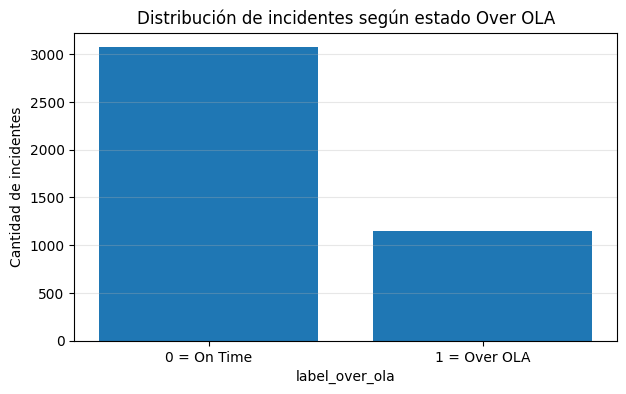

In [4]:
ola_counts = incidents['label_over_ola'].value_counts().sort_index()
ola_table = pd.DataFrame({
    'label_over_ola': ola_counts.index,
    'cantidad': ola_counts.values,
    'porcentaje': (ola_counts.values / len(incidents) * 100).round(2)
})
display(ola_table)

plt.figure(figsize=(7,4))
plt.bar(ola_table['label_over_ola'].astype(str), ola_table['cantidad'])
plt.title('Distribución de incidentes según estado Over OLA')
plt.xlabel('label_over_ola')
plt.ylabel('Cantidad de incidentes')
plt.xticks([0,1], ['0 = On Time', '1 = Over OLA'])
plt.grid(axis='y', alpha=0.3)
plt.show()


## 4. Análisis exploratorio de incidentes históricos

Se revisa el comportamiento por área, tipo de causa agrupada y duración. Esto ayuda a identificar patrones relevantes para el modelo.


,area,cantidad
0,TXNOC,4215


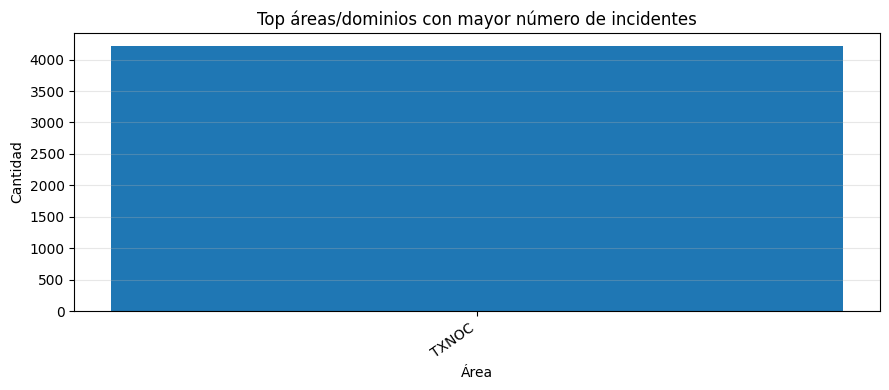

In [5]:
area_counts = incidents['area'].fillna('unknown').value_counts().head(10)
display(pd.DataFrame({'area': area_counts.index, 'cantidad': area_counts.values}))

plt.figure(figsize=(9,4))
plt.bar(area_counts.index.astype(str), area_counts.values)
plt.title('Top áreas/dominios con mayor número de incidentes')
plt.xlabel('Área')
plt.ylabel('Cantidad')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


,reason_group,cantidad
0,fiber_cable,2544
1,attenuation,643
2,equipment_module,538
3,link_down,237
4,other,161
5,power_energy,40
6,logical_config,35
7,temperature_environment,17


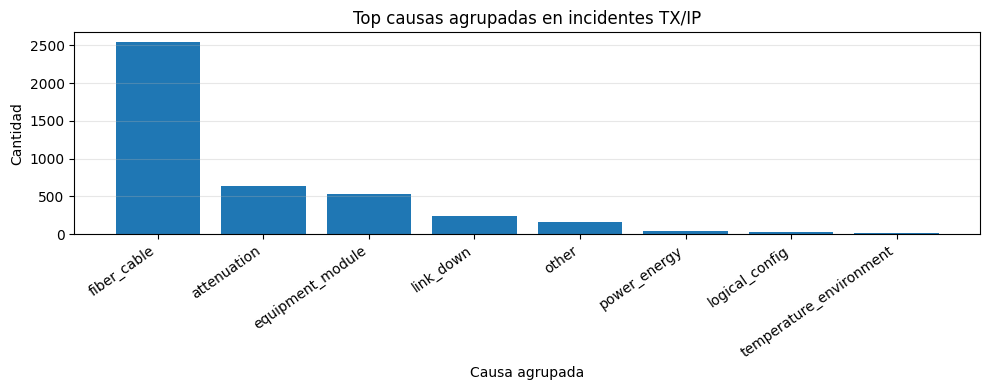

In [6]:
reason_counts = incidents['reason_group'].fillna('unknown').value_counts().head(10)
display(pd.DataFrame({'reason_group': reason_counts.index, 'cantidad': reason_counts.values}))

plt.figure(figsize=(10,4))
plt.bar(reason_counts.index.astype(str), reason_counts.values)
plt.title('Top causas agrupadas en incidentes TX/IP')
plt.xlabel('Causa agrupada')
plt.ylabel('Cantidad')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


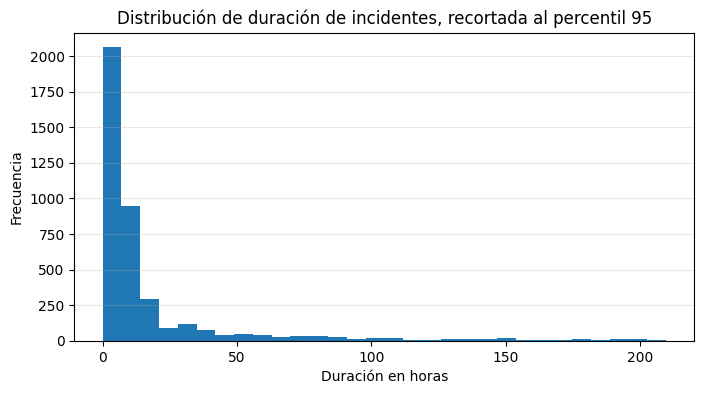

Percentil 95 de duración: 209.78 horas
Duración promedio: 46.62 horas
Duración mediana: 7.00 horas


In [7]:
q95 = incidents['duration_hours'].quantile(0.95)
duration_trim = incidents[incidents['duration_hours'] <= q95]

plt.figure(figsize=(8,4))
plt.hist(duration_trim['duration_hours'].dropna(), bins=30)
plt.title('Distribución de duración de incidentes, recortada al percentil 95')
plt.xlabel('Duración en horas')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f'Percentil 95 de duración: {q95:.2f} horas')
print(f'Duración promedio: {incidents["duration_hours"].mean():.2f} horas')
print(f'Duración mediana: {incidents["duration_hours"].median():.2f} horas')


## 5. Análisis exploratorio de alarmas actuales

La segunda fuente de datos permite mostrar avance adicional en el sprint: no solo se analizan incidentes cerrados, también se incorporan alarmas actuales que pueden servir para priorización temprana.


,severity,cantidad
0,CRITICAL,4025
1,MAJOR,4


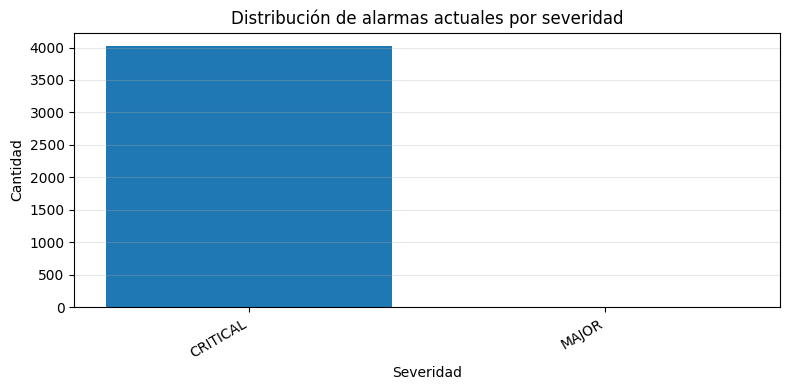

In [8]:
severity_counts = alarms['severity'].fillna('unknown').value_counts().head(10)
display(pd.DataFrame({'severity': severity_counts.index, 'cantidad': severity_counts.values}))

plt.figure(figsize=(8,4))
plt.bar(severity_counts.index.astype(str), severity_counts.values)
plt.title('Distribución de alarmas actuales por severidad')
plt.xlabel('Severidad')
plt.ylabel('Cantidad')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


,reason_group_candidate,cantidad
0,link_down,3326
1,equipment_module,497
2,other,132
3,power_energy,69
4,temperature_environment,4
5,fiber_cable,1


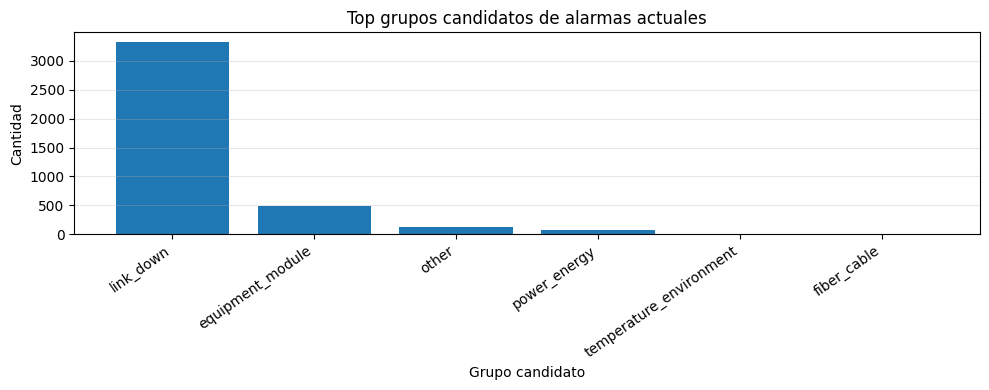

In [9]:
alarm_group_counts = alarms['reason_group_candidate'].fillna('unknown').value_counts().head(10)
display(pd.DataFrame({'reason_group_candidate': alarm_group_counts.index, 'cantidad': alarm_group_counts.values}))

plt.figure(figsize=(10,4))
plt.bar(alarm_group_counts.index.astype(str), alarm_group_counts.values)
plt.title('Top grupos candidatos de alarmas actuales')
plt.xlabel('Grupo candidato')
plt.ylabel('Cantidad')
plt.xticks(rotation=35, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


,candidate_risk_score,severity,reason_group_candidate,alarm_age_hours
3200,0.88,CRITICAL,link_down,750.86
3201,0.88,CRITICAL,link_down,741.66
3202,0.88,CRITICAL,link_down,732.58
3203,0.88,CRITICAL,link_down,725.27
3204,0.88,CRITICAL,link_down,722.18
56,0.88,CRITICAL,equipment_module,73505.55
57,0.88,CRITICAL,equipment_module,73505.20
58,0.88,CRITICAL,equipment_module,73505.20
59,0.88,CRITICAL,equipment_module,73505.20
60,0.88,CRITICAL,equipment_module,73505.20


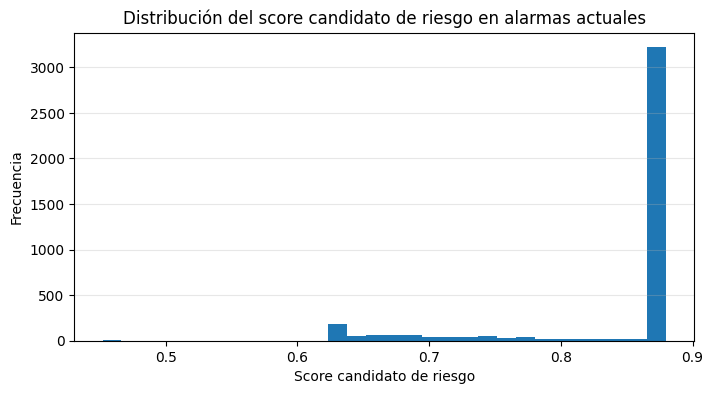

In [10]:
risk_col = 'candidate_risk_score'
if risk_col in alarms.columns:
    display(alarms[[risk_col, 'severity', 'reason_group_candidate', 'alarm_age_hours']].sort_values(risk_col, ascending=False).head(10))
    plt.figure(figsize=(8,4))
    plt.hist(alarms[risk_col].dropna(), bins=30)
    plt.title('Distribución del score candidato de riesgo en alarmas actuales')
    plt.xlabel('Score candidato de riesgo')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
else:
    print('No se encontró candidate_risk_score en el dataset de alarmas.')


## 6. Resultados comparables: baseline vs variantes A/B

Para la entrega de semana 6 se comparan tres enfoques:

- **Baseline:** regla operacional simple.
- **Var1:** Logistic Regression.
- **Var2:** Random Forest.

La comparación permite justificar técnicamente qué variante se adopta.


,experimento,modelo,precision_over_ola,recall_over_ola,f1_over_ola,average_precision,train_time_sec,latency_ms_per_1000
0,Baseline,Regla operacional,0.1922,1.0000,0.3224,0.1850,0.0000,2.7079
1,Var1,LogisticRegression,0.4467,0.6728,0.5369,0.4413,0.0526,6.4577
2,Var2,RandomForestClassifier,0.4375,0.7346,0.5484,0.3888,1.5331,296.5485


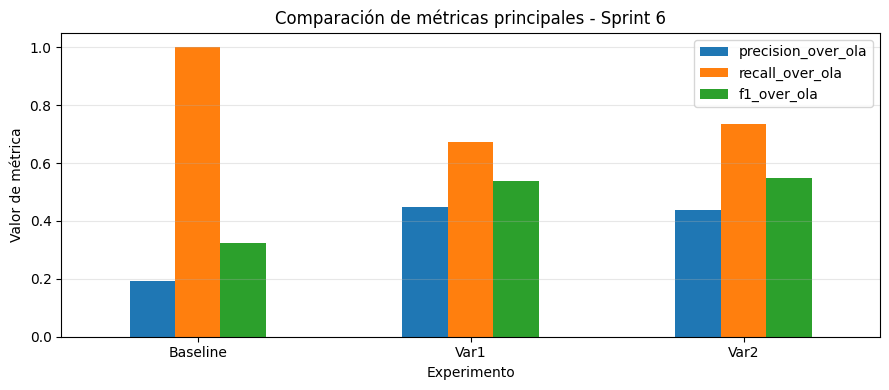

In [11]:
cols = ['experimento', 'modelo', 'precision_over_ola', 'recall_over_ola', 'f1_over_ola', 'average_precision', 'train_time_sec', 'latency_ms_per_1000']
display(metrics[cols])

plot_df = metrics.set_index('experimento')[['precision_over_ola', 'recall_over_ola', 'f1_over_ola']]
ax = plot_df.plot(kind='bar', figsize=(9,4))
ax.set_title('Comparación de métricas principales - Sprint 6')
ax.set_xlabel('Experimento')
ax.set_ylabel('Valor de métrica')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Curva Precision-Recall

La curva Precision-Recall muestra el equilibrio entre detectar más casos reales sobre OLA y mantener alertas confiables.

En un entorno NOC, este análisis es importante porque el modelo debe apoyar la priorización sin saturar al operador con demasiados falsos positivos.


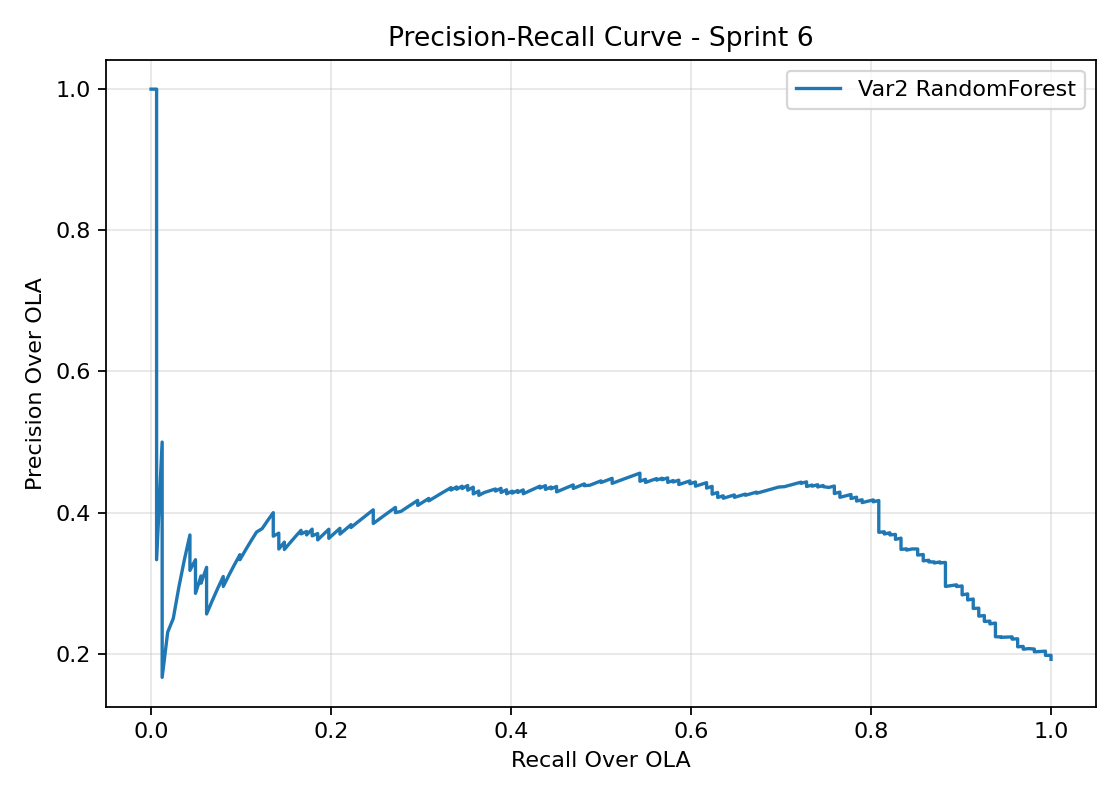

In [12]:
from IPython.display import Image, display
pr_curve_path = RESULTS_DIR / 'pr_curve_sprint6.png'
if pr_curve_path.exists():
    display(Image(filename=str(pr_curve_path)))
else:
    print('No se encontró pr_curve_sprint6.png en results/.')


## 8. Resumen EDA y riesgos identificados

Esta sección resume los principales hallazgos del análisis exploratorio y los riesgos metodológicos que deben controlarse en los siguientes sprints.


In [13]:
print('===== RESUMEN DEL ANALISIS EXPLORATORIO =====')
print()
print('DATASET:')
print(f'- Total incidentes TX/IP anonimizados: {len(incidents)}')
print(f'- Total alarmas actuales anonimizadas: {len(alarms)}')
print(f'- Variables incidentes: {incidents.shape[1]}')
print(f'- Variables alarmas: {alarms.shape[1]}')
print()
print('VARIABLE OBJETIVO:')
print(f'- Casos Over OLA: {int((incidents["label_over_ola"] == 1).sum())}')
print(f'- Casos On Time: {int((incidents["label_over_ola"] == 0).sum())}')
print()
print('RESULTADO MODELO:')
best = metrics.sort_values('f1_over_ola', ascending=False).iloc[0]
print(f'- Variante recomendada: {best["experimento"]} - {best["modelo"]}')
print(f'- Precision Over OLA: {best["precision_over_ola"]:.4f}')
print(f'- Recall Over OLA: {best["recall_over_ola"]:.4f}')
print(f'- F1 Over OLA: {best["f1_over_ola"]:.4f}')
print()
print('RIESGOS IDENTIFICADOS:')
print('- Posible desbalance entre incidentes On Time y Over OLA.')
print('- Riesgo de leakage si se usan campos que solo se conocen al cierre del incidente.')
print('- Riesgo de drift operativo si cambian patrones de red, mantenimiento o alarmas.')
print('- Se requiere fortalecer validación temporal y explicación de variables importantes.')


===== RESUMEN DEL ANALISIS EXPLORATORIO =====

DATASET:
- Total incidentes TX/IP anonimizados: 4215
- Total alarmas actuales anonimizadas: 4029
- Variables incidentes: 18
- Variables alarmas: 19

VARIABLE OBJETIVO:
- Casos Over OLA: 1144
- Casos On Time: 3071

RESULTADO MODELO:
- Variante recomendada: Var2 - RandomForestClassifier
- Precision Over OLA: 0.4375
- Recall Over OLA: 0.7346
- F1 Over OLA: 0.5484

RIESGOS IDENTIFICADOS:
- Posible desbalance entre incidentes On Time y Over OLA.
- Riesgo de leakage si se usan campos que solo se conocen al cierre del incidente.
- Riesgo de drift operativo si cambian patrones de red, mantenimiento o alarmas.
- Se requiere fortalecer validación temporal y explicación de variables importantes.


## 9. Decisión del Sprint 6

La variante adoptada para este sprint es **Random Forest**, porque logra el mejor equilibrio general entre `recall`, `precision` y `F1` para la clase **Over OLA**.

El modelo no reemplaza al operador NOC. Su propósito es funcionar como una herramienta de apoyo para priorizar incidentes y alarmas con mayor riesgo operativo.


## 10. Reproducibilidad

Comandos sugeridos para reproducir el experimento desde la raíz del repositorio:

```bash
pip install -r requirements.txt
python src/train_sprint6_ab.py
```

Archivos principales:

- Datos procesados: `data/processed/`
- Notebook EDA: `notebooks/00_EDA_basico_NOC_sprint6.ipynb`
- Experimentos A/B: `notebooks/01_sprint6_ab_experiments.ipynb`
- Métricas: `results/metrics_ab_sprint6.csv`
- Curva PR: `results/pr_curve_sprint6.png`
- Logs: `logs/sprint6_run.log`
